In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("World_Cup.csv")
df.head(3)

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18


## 1. Date și tipuri: calitative vs cantitative

**Categorii  (Calitative)** descriu calități (texte):
- **Nominal**: categorii fără ordine naturală (ex.: țara câștigătoare, nume de țări). Nu are sens să „ordonezi” Brazilia înaintea Italiei doar din nume.
- **Ordinal**: categorii cu ordine logică, dar diferențele între trepte nu sunt neapărat egale (ex.: clasament final 1–4: câștigător, finalist, loc 3, loc 4).

**Numerice  (Cantitative)** pot fi măsurate sau numărate:
- **Discrete**: valori numărabile, de obicei întregi (ex.: număr de echipe calificate, meciuri jucate, goluri marcate în turneu — deși golurile sunt „numărabile”, le tratăm adesea ca discrete în context).
- **Continuu** (în teorie): orice valoare dintr-un interval; în setul nostru, anul poate fi tratat ca temporal; pentru simplificare, `Year` apare ca întregi, dar timpul este continuu în realitate. Coloanele `GoalsScored`, `QualifiedTeams`, `MatchesPlayed` sunt cantitative discrete în practică.


In [4]:
df.dtypes

Year               int64
Country           object
Winner            object
Runners-Up        object
Third             object
Fourth            object
GoalsScored        int64
QualifiedTeams     int64
MatchesPlayed      int64
dtype: object

In [5]:
df.describe()

,Year,GoalsScored,QualifiedTeams,MatchesPlayed
count,22.000000,22.000000,22.000000,22.000000
mean,1978.909091,123.636364,22.227273,43.818182
std,27.738419,34.841882,7.602830,17.632860
min,1930.000000,70.000000,13.000000,17.000000
25%,1959.000000,90.500000,16.000000,32.000000
50%,1980.000000,129.000000,20.000000,45.000000
75%,2001.000000,146.750000,32.000000,64.000000
max,2022.000000,172.000000,32.000000,64.000000


## 2. Tendențe centrale: medie, mediană, frecvență (mode/most)

- **Medie (mean)**: suma valorilor / numărul de valori; sensibilă la valori extreme.
- **Mediană (median)**: valoarea din mijloc după sortare (sau media celor două din mijloc); mai robustă la outlier-e.
- **Modă (mode)**: valoarea (sau categoria) cea mai frecventă; pentru date calitative, „cea mai comună categorie”.


In [7]:
s_gs = df["GoalsScored"]
medie = s_gs.mean()
median = s_gs.median()
mode = s_gs.mode()
mode

0     70
1     89
2    171
Name: GoalsScored, dtype: int64

## 3. Măsurarea spread-ului (împrăștierii datelor) 

- **Range (interval)** Intervalul este o măsură a variației, care descrie cât de dispersate sunt datele.
- **IQR (Interquartile Range)**: Intervalul intercuartil este o măsură a variației, care descrie cât de dispersate sunt datele
- **Standard Deviation**: Abaterea standard este cea mai frecvent utilizată măsură a variației, care descrie cât de dispersate sunt datele.

In [8]:
s_gs.describe()

count     22.000000
mean     123.636364
std       34.841882
min       70.000000
25%       90.500000
50%      129.000000
75%      146.750000
max      172.000000
Name: GoalsScored, dtype: float64

## 4. Tipuri de grafice: categorice vs numerice (calitative vs cantitative)

**Calitative (categorii)** descriu calități, nu mărimi numerice directe:
- **Bar Chart** Arată frecvența valorilor din date
- **Pie Chart** Arată frecvența sau frecvența relativă a valorilor din date.



In [10]:
df["Winner"]

0        Uruguay
1          Italy
2          Italy
3        Uruguay
4     Germany FR
5         Brazil
6         Brazil
7        England
8         Brazil
9     Germany FR
10     Argentina
11         Italy
12     Argentina
13    Germany FR
14        Brazil
15        France
16        Brazil
17         Italy
18         Spain
19       Germany
20        France
21     Argentina
Name: Winner, dtype: object

In [9]:
winners = df["Winner"].value_counts()
winners

Winner
Brazil        5
Italy         4
Germany FR    3
Argentina     3
Uruguay       2
France        2
England       1
Spain         1
Germany       1
Name: count, dtype: int64

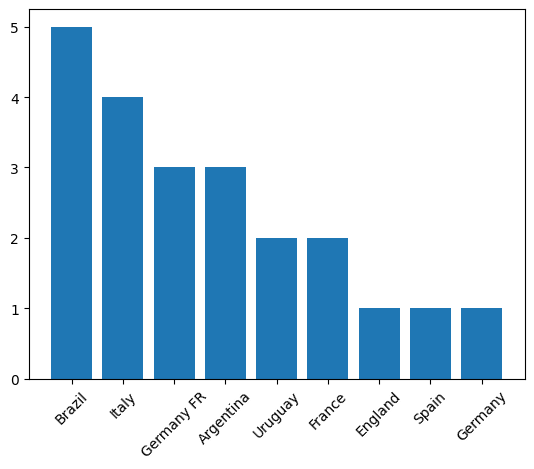

In [12]:
plt.bar(winners.index, winners.values)
plt.xticks(rotation=45);

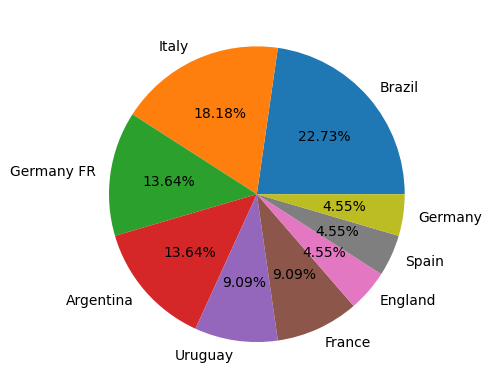

In [21]:
plt.pie(winners.values, labels=winners.index, autopct="%1.2f%%")
plt.xticks(rotation=45);

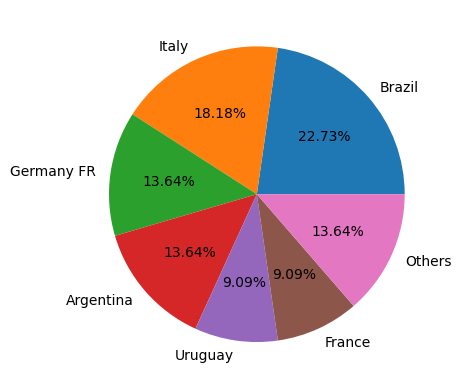

In [22]:
top6 = winners.head(6)
other = winners.iloc[6:].sum()

pie_size = list(top6.values) + ([other])
pie_size_labels = list(top6.index) + (["Others"])

plt.pie(pie_size, labels=pie_size_labels, autopct="%1.2f%%")
plt.xticks(rotation=45);


In [ ]:
plt.pie(winners.values, labels=winners.index, autopct="%1.1f%%")
plt.xticks(rotation=45);


**Cantitative (numerice)** pot fi măsurate sau numărate:
- **Histogram**: Arată frecvența valorilor din date, de obicei în intervale de valori.
- **BoxPlot**: Arată mediana datelor. Aceasta este valoarea din mijloc a datelor și un tip de valoare medie. De asemenea, arată intervalul și quartilele datelor.

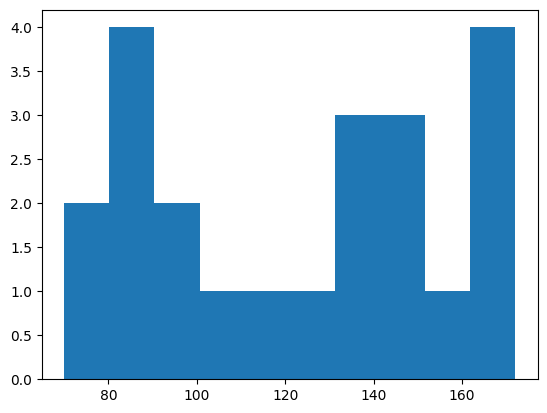

In [24]:
plt.hist(df["GoalsScored"]);

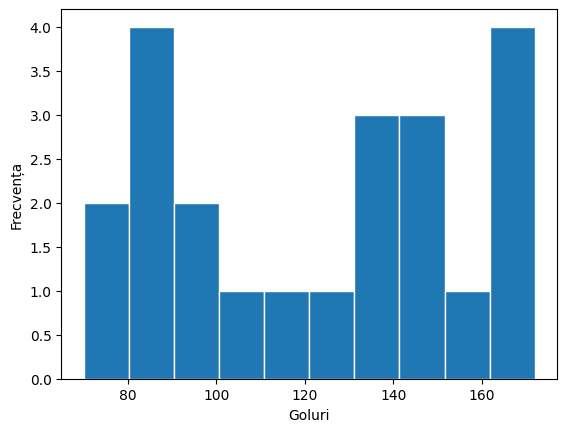

In [32]:
plt.hist(df["GoalsScored"], edgecolor="white")
plt.xlabel("Goluri")
plt.ylabel("Frecvența");

(array([2., 5., 2., 1., 2., 4., 1., 5.]),
 array([ 70.  ,  82.75,  95.5 , 108.25, 121.  , 133.75, 146.5 , 159.25,
        172.  ]),
 <BarContainer object of 8 artists>)

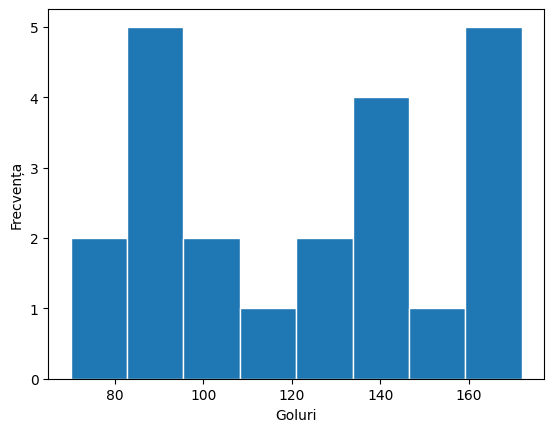

In [ ]:
plt.xlabel("Goluri")
plt.ylabel("Frecvența")
plt.hist(df["GoalsScored"], edgecolor="white", bins=8)

(array([4., 1., 3., 3., 0., 4., 0., 7.]),
 array([17.   , 22.875, 28.75 , 34.625, 40.5  , 46.375, 52.25 , 58.125,
        64.   ]),
 <BarContainer object of 8 artists>)

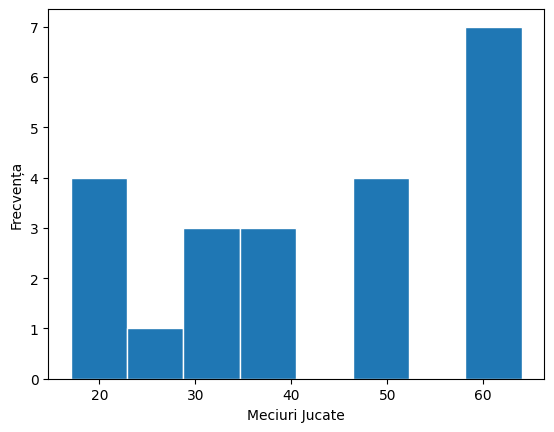

In [37]:
plt.xlabel("Meciuri Jucate")
plt.ylabel("Frecvența")
plt.hist(df["MatchesPlayed"], edgecolor="white", bins=8)

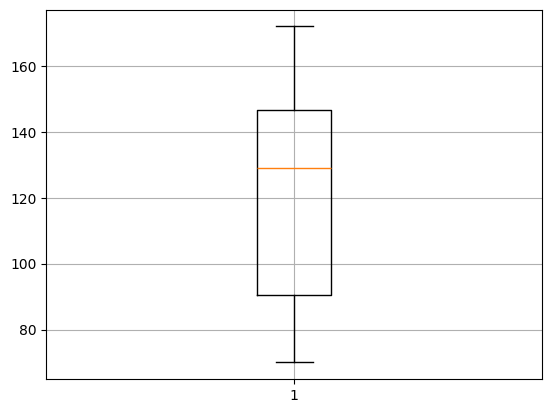

In [40]:
plt.boxplot(df["GoalsScored"]);
plt.grid()

In [39]:
df["GoalsScored"].describe()

count     22.000000
mean     123.636364
std       34.841882
min       70.000000
25%       90.500000
50%      129.000000
75%      146.750000
max      172.000000
Name: GoalsScored, dtype: float64

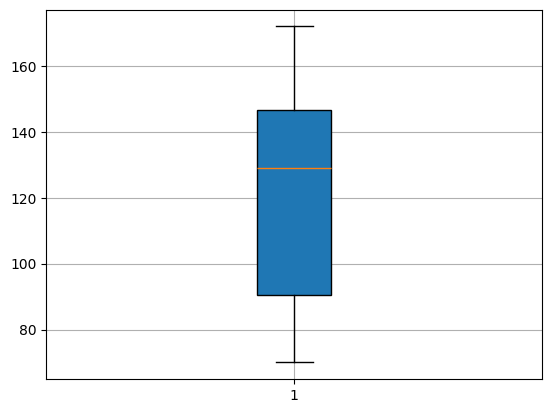

In [43]:
boxpolot_gs = plt.boxplot(df["GoalsScored"], patch_artist=True);
plt.grid()